In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [31]:
df = pd.read_csv('../data/CleanedSalesData.csv')
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,...,Total_Amount,Total_Sales,Avg_Item_Price,Discount_Percentage,Profit,Profit_Margin,Engagement_Score,Pages_Per_Minute,Is_Delayed,Rating_Category
0,ORD_000001-1,CUST_00001,2023-05-28,40,Male,Delhi (NCR),Books,29.18,1,0.00,...,29.18,29.18,29.18,0.000000,8.754,30.000000,126,0.642857,True,Excellent
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Delhi (NCR),Home & Garden,644.40,1,138.05,...,506.35,506.35,506.35,21.423029,55.270,10.915375,112,0.571429,False,Poor
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Delhi (NCR),Sports,332.82,5,0.00,...,1664.10,1664.10,332.82,0.000000,499.230,30.000000,150,0.666667,True,Excellent
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Bengaluru,Food,69.30,5,71.05,...,275.45,275.45,55.09,20.505051,32.900,11.944091,208,0.812500,False,Excellent
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Bengaluru,Beauty,178.15,3,0.00,...,534.45,534.45,178.15,0.000000,160.335,30.000000,98,0.500000,False,Excellent


In [32]:
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=[object]).columns.tolist()
    

In [33]:
numerical_features

['Age',
 'Unit_Price',
 'Quantity',
 'Discount_Amount',
 'Session_Duration_Minutes',
 'Pages_Viewed',
 'Delivery_Time_Days',
 'Customer_Rating',
 'Cost_Price',
 'Cart_Size',
 'Total_Amount',
 'Total_Sales',
 'Avg_Item_Price',
 'Discount_Percentage',
 'Profit',
 'Profit_Margin',
 'Engagement_Score',
 'Pages_Per_Minute']

In [34]:
categorical_features

['Order_ID',
 'Customer_ID',
 'Date',
 'Gender',
 'City',
 'Product_Category',
 'Payment_Method',
 'Device_Type',
 'Rating_Category']

# Exploratory Data Analysis (EDA)

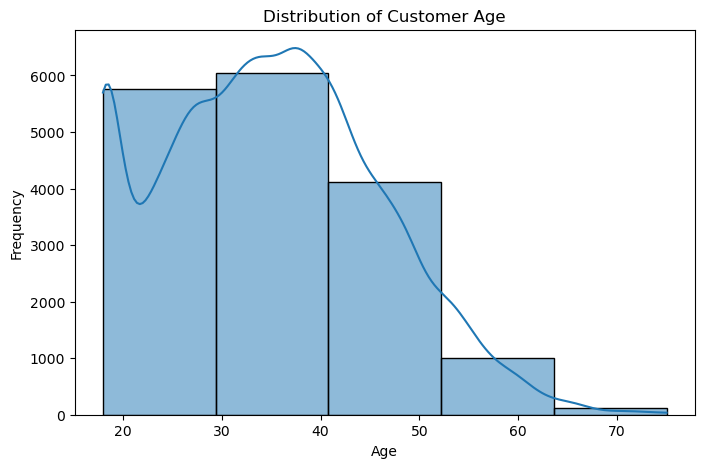

In [35]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", bins=5, kde=True)

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [36]:
df['City'].value_counts()

City
Bengaluru      4402
Delhi (NCR)    2422
Mumbai         2072
Hyderabad      1721
Pune           1326
Chennai        1246
Kolkata        1183
Ahmedabad      1120
Lucknow         851
Jaipur          706
Name: count, dtype: int64

In [37]:
print("Earliest Date:", df["Date"].min())
print("Latest Date:", df["Date"].max())

Earliest Date: 2023-01-01
Latest Date: 2024-03-25


In [38]:
df['Product_Category'].value_counts()

Product_Category
Sports           2248
Beauty           2212
Books            2206
Food             2103
Toys             2090
Electronics      2074
Home & Garden    2060
Fashion          2056
Name: count, dtype: int64

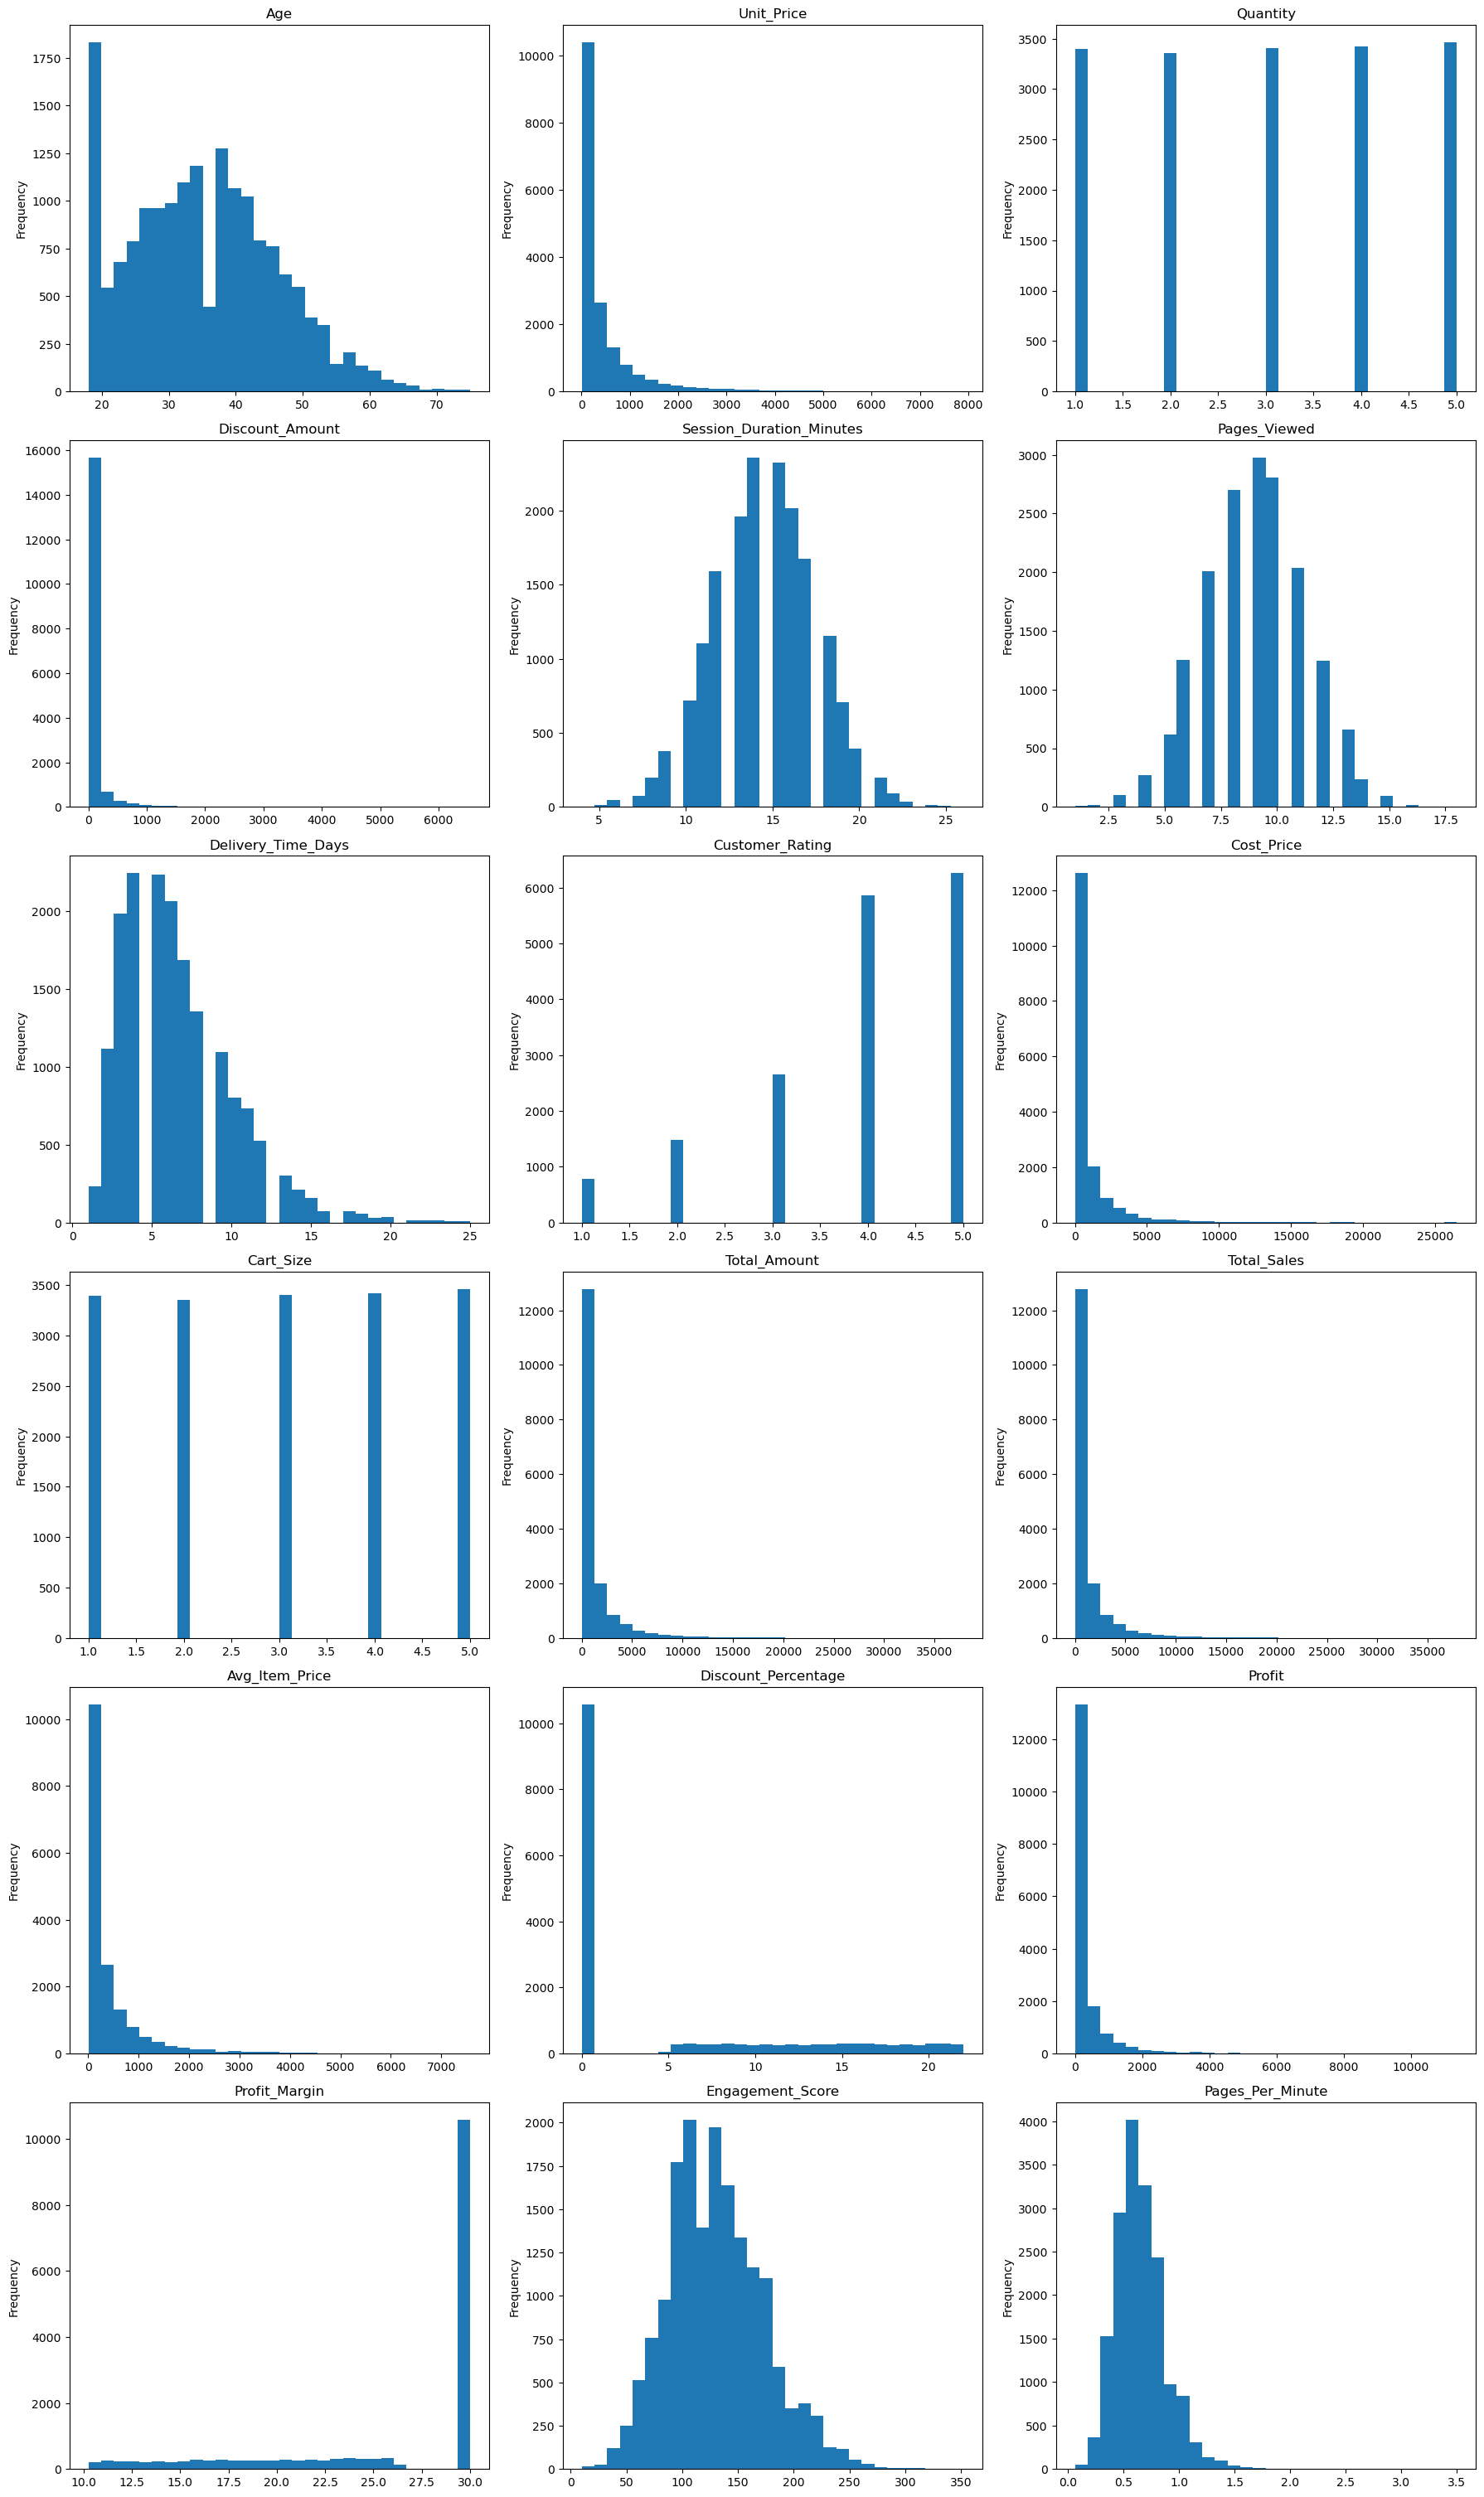

In [39]:
num_cols = df.select_dtypes(include=np.number).columns

fig, axes = plt.subplots(len(num_cols)//3 + 1, 3, figsize=(18, 5*(len(num_cols)//3 + 1))
)

axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    ax.hist(df[col], bins=30)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")

# Remove empty plots
for ax in axes[len(num_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

# Inference

## Key Observations

### Age
- Customer ages are concentrated between approximately **25 and 45 years**.
- The distribution is slightly right-skewed, indicating relatively fewer older customers.
- The dataset primarily represents young and middle-aged customers.

### Unit Price
- The distribution is highly right-skewed.
- Most products have relatively low prices, while only a small number of products are expensive.
- This pattern is commonly observed in e-commerce datasets where affordable products dominate sales.

### Quantity
- The quantity purchased ranges from **1 to 5 units**.
- All purchase quantities appear to be relatively balanced, indicating that customers buy varying numbers of products without a strong preference for a single quantity.

### Discount Amount
- Most orders receive relatively small discounts.
- A few transactions have significantly larger discounts, resulting in a long right tail.
- This suggests occasional promotional or high-value discounted purchases.

### Session Duration
- Customer session duration follows an approximately normal distribution.
- Most shopping sessions last between **10 and 18 minutes**.
- Extremely short and extremely long sessions are relatively uncommon.

### Pages Viewed
- The number of pages viewed also follows an approximately bell-shaped distribution.
- Most customers browse between **7 and 11 pages** before completing or leaving a session.
- Browsing behavior appears consistent across customers.

### Delivery Time
- Most deliveries are completed within **3 to 8 days**.
- A small number of deliveries take significantly longer, producing a right-skewed distribution.
- These delayed deliveries may require further investigation during later analysis.

### Customer Rating
- Customer ratings are concentrated toward higher values, particularly **4 and 5 stars**.
- This indicates generally high customer satisfaction across orders.

### Cost Price
- Estimated cost prices exhibit a strong right-skew similar to product prices.
- Most products have relatively low estimated costs, while only a few products contribute very high costs.

### Cart Size
- Cart sizes range from **1 to 5 items**.
- Purchases appear relatively evenly distributed across the available cart sizes.

### Total Amount
- Transaction values are highly right-skewed.
- Most purchases involve relatively low spending, while a small number of high-value orders contribute substantially to total revenue.

### Total Sales
- Since Total Sales is derived directly from Total Amount, both variables exhibit identical distributions.

### Average Item Price
- The average selling price per item is strongly right-skewed.
- Most purchased products fall within lower price ranges, with relatively few premium-priced products.

### Discount Percentage
- Most transactions receive relatively low percentage discounts.
- Higher discount percentages occur less frequently, indicating that aggressive discounts are comparatively rare.

### Profit
- Profit follows a right-skewed distribution.
- The majority of orders generate modest profits, while only a few transactions contribute exceptionally high profits.

### Profit Margin
- Profit margins are concentrated near the upper end of the distribution.
- This is expected because the estimated cost price was assumed to be a fixed percentage of the selling price, resulting in relatively consistent margins across transactions.

### Engagement Score
- Engagement Score exhibits an approximately normal distribution.
- Most customers demonstrate moderate engagement levels, with very high or very low engagement occurring less frequently.

### Pages Per Minute
- Pages viewed per minute show a mild right-skew.
- Most customers browse at a similar pace, while a few users navigate considerably faster than average.

---

# Summary

The univariate analysis reveals several important characteristics of the dataset:

- Most monetary variables (Unit Price, Total Amount, Total Sales, Profit, Cost Price, and Average Item Price) exhibit **strong positive skewness**, indicating that a small number of high-value transactions contribute disproportionately to overall revenue and profit.

- Customer behavioral variables such as **Session Duration**, **Pages Viewed**, and **Engagement Score** are approximately normally distributed, suggesting consistent browsing patterns among customers.

- Delivery performance indicates that the majority of orders are delivered within the expected timeframe, although a small proportion experience noticeable delays.

- Customer ratings are heavily concentrated toward higher values, indicating generally positive customer experiences.

- No unexpected distributional patterns or obvious data quality issues are observed, suggesting that the dataset is well-prepared for subsequent bivariate analysis, correlation analysis, and visualization.

In [40]:
df['Rating_Category'].value_counts()

Rating_Category
Excellent    12123
Average       2658
Poor          2268
Name: count, dtype: int64

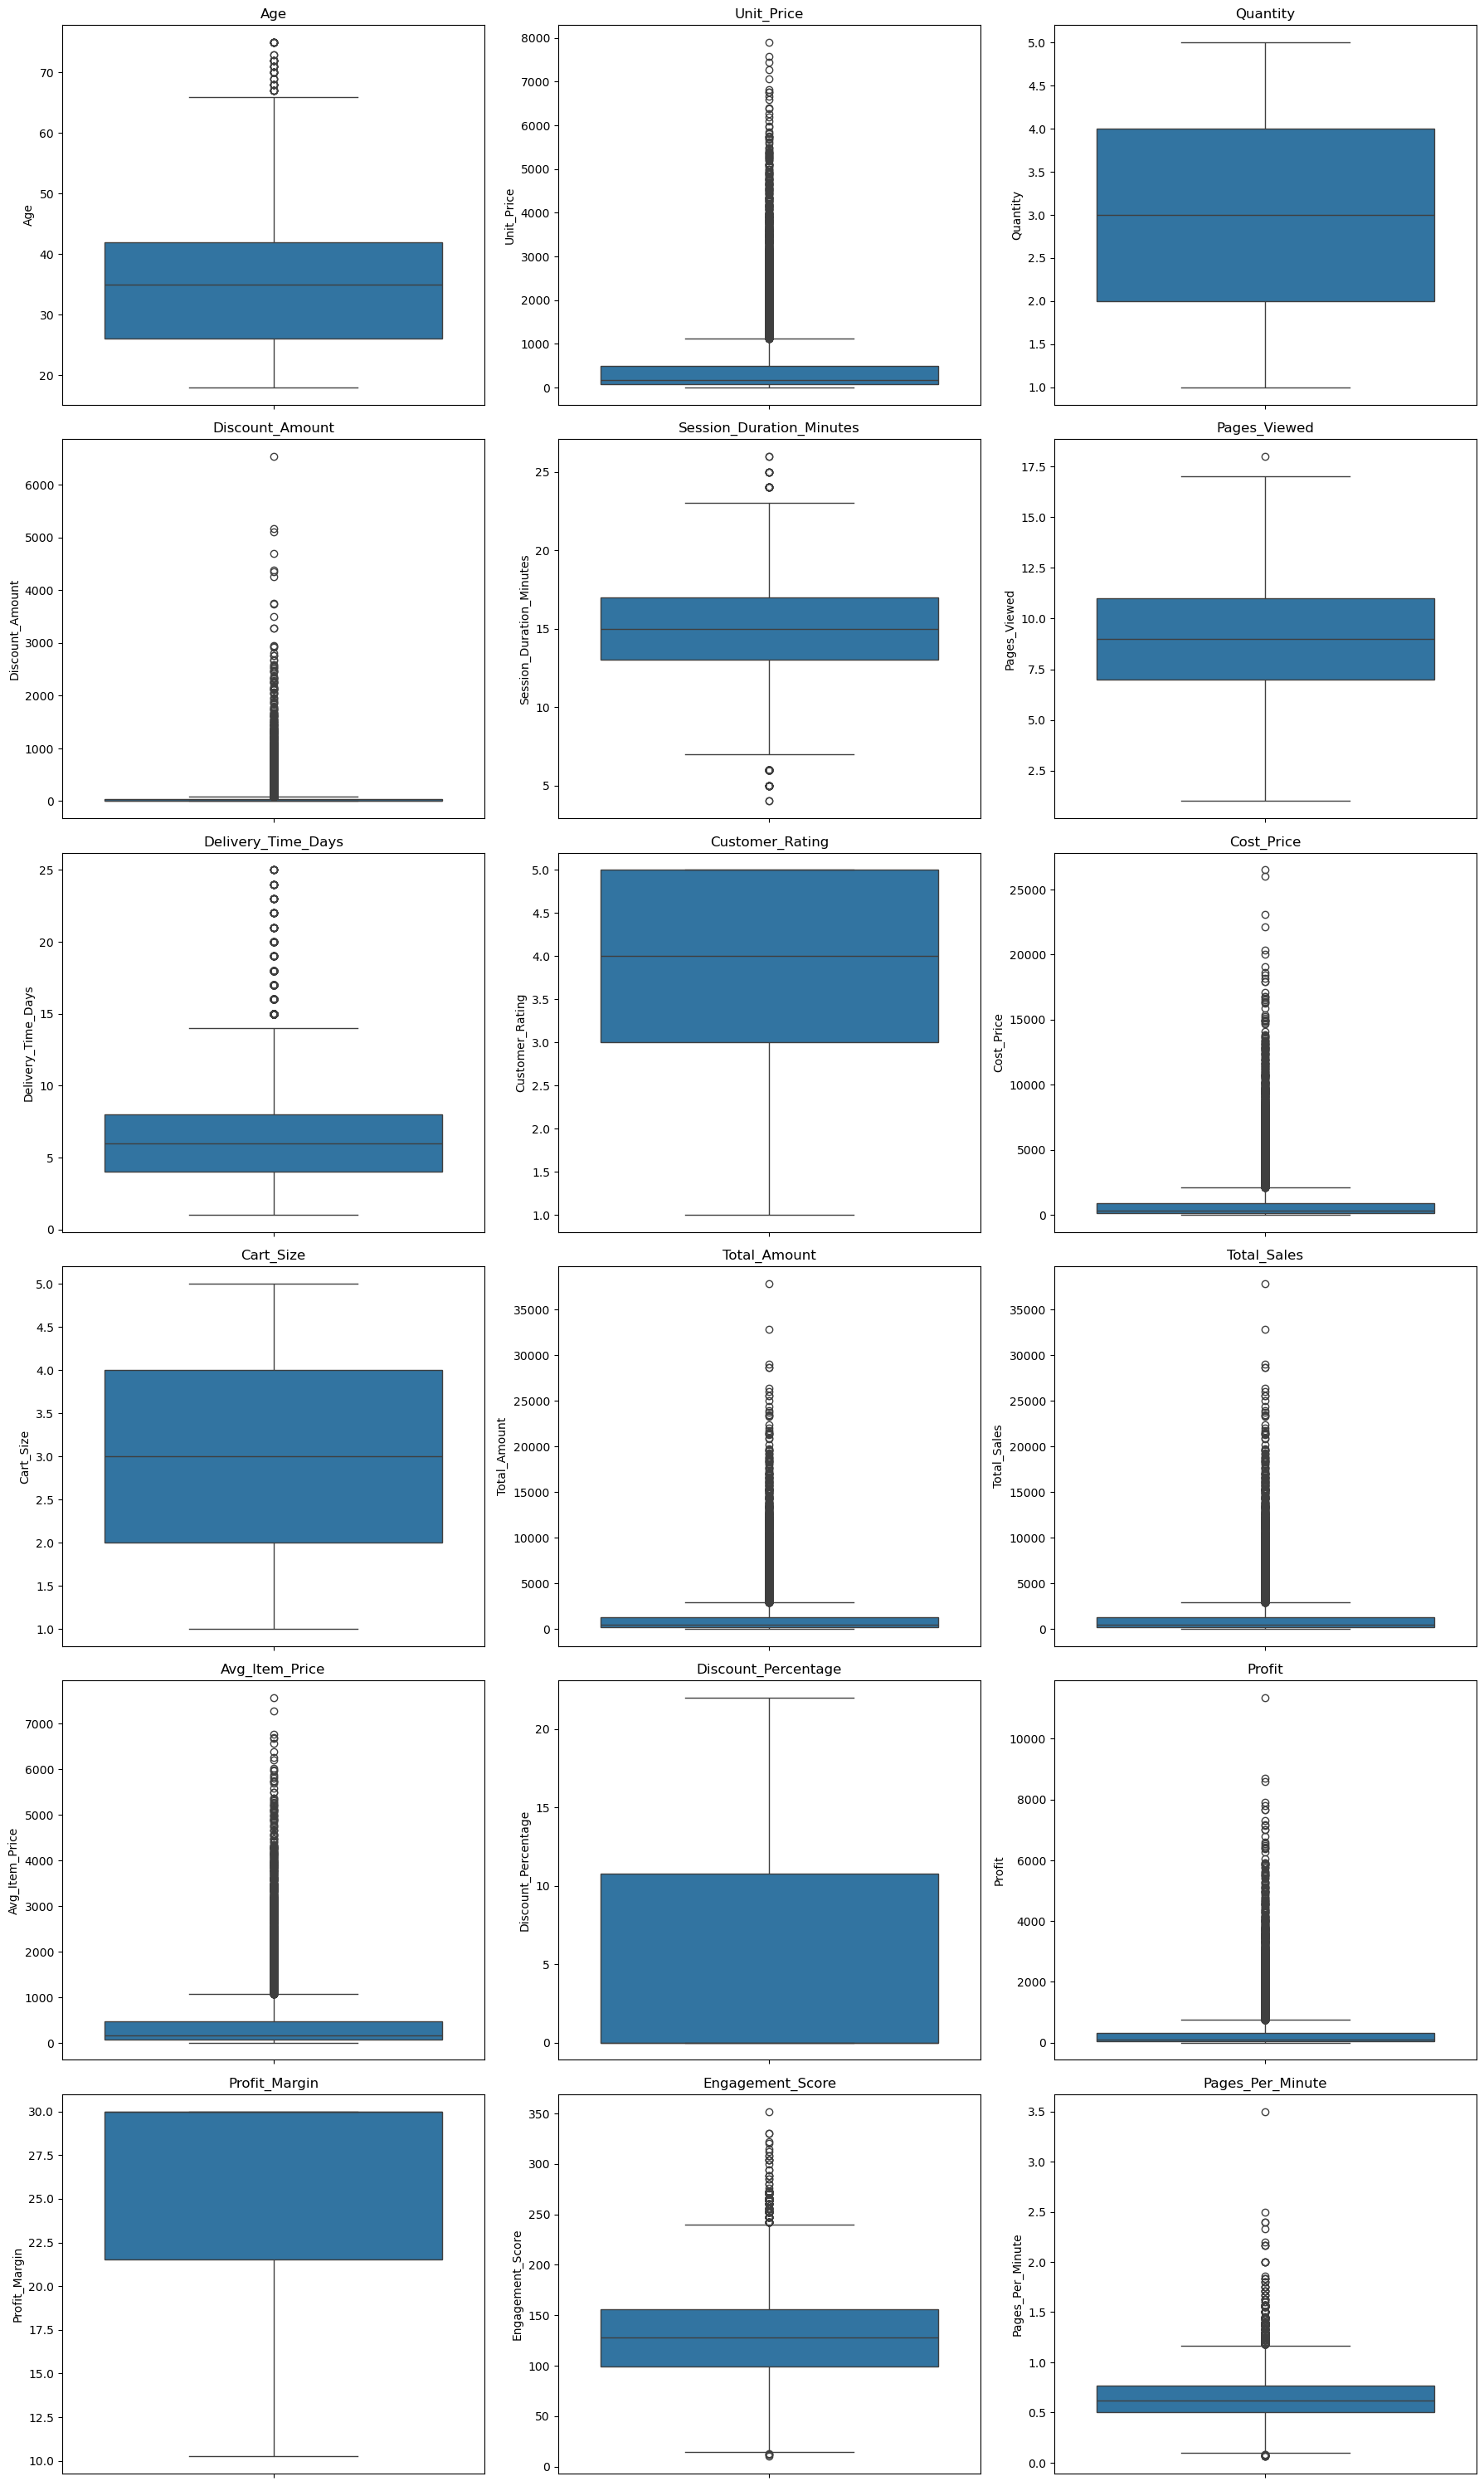

In [41]:
fig, axes = plt.subplots(len(num_cols)//3 + 1, 3, figsize=(18, 5*(len(num_cols)//3 + 1)))

axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)

for ax in axes[len(num_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

# Outlier Analysis Using Boxplots

The boxplots indicate that the majority of outliers are concentrated in **monetary variables**, including Unit Price, Cost Price, Total Amount, Total Sales, Average Item Price, and Profit. These values most likely represent legitimate high-value transactions rather than data inconsistencies.

Behavioral variables such as Session Duration, Pages Viewed, Engagement Score, and Pages Per Minute contain relatively few outliers, indicating generally consistent customer browsing patterns.

Since this is an e-commerce dataset, high-value transactions are expected and provide valuable business insights. Therefore, **no outliers were removed** during preprocessing, as eliminating them could lead to the loss of meaningful information and potentially bias subsequent analyses.

In [45]:
cols=[ 'City', 'Product_Category', 'Payment_Method', 'Device_Type', 'Rating_Category' ]

for col in cols:
    print(col)
    print(df[col].value_counts())
    print()

City
City
Bengaluru      4402
Delhi (NCR)    2422
Mumbai         2072
Hyderabad      1721
Pune           1326
Chennai        1246
Kolkata        1183
Ahmedabad      1120
Lucknow         851
Jaipur          706
Name: count, dtype: int64

Product_Category
Product_Category
Sports           2248
Beauty           2212
Books            2206
Food             2103
Toys             2090
Electronics      2074
Home & Garden    2060
Fashion          2056
Name: count, dtype: int64

Payment_Method
Payment_Method
Credit Card         6801
Debit Card          4321
Digital Wallet      3276
Bank Transfer       1763
Cash on Delivery     888
Name: count, dtype: int64

Device_Type
Device_Type
Mobile     9543
Desktop    5845
Tablet     1661
Name: count, dtype: int64

Rating_Category
Rating_Category
Excellent    12123
Average       2658
Poor          2268
Name: count, dtype: int64



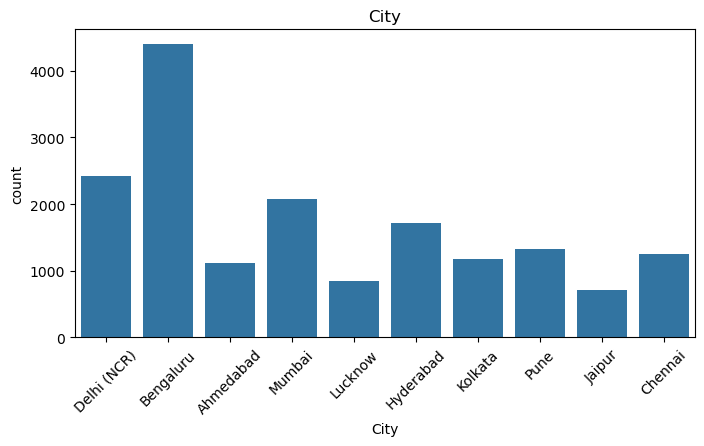

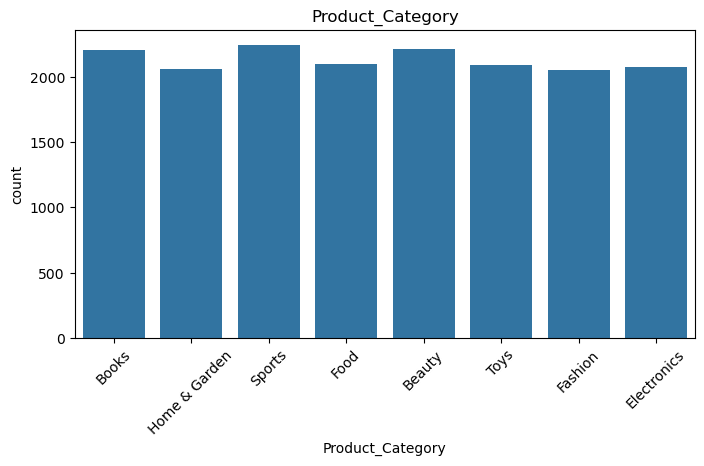

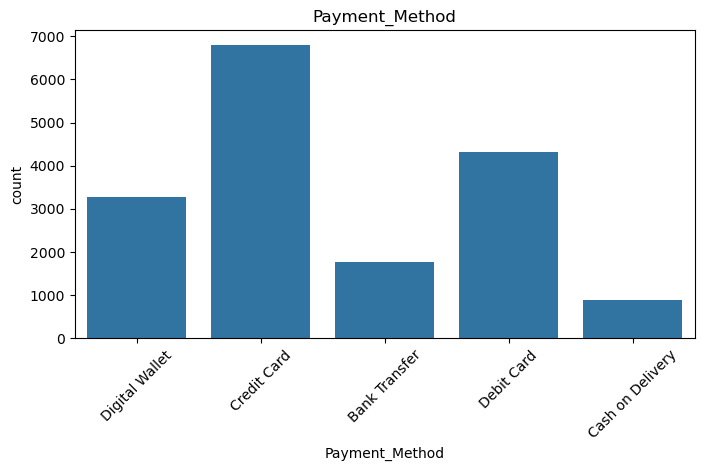

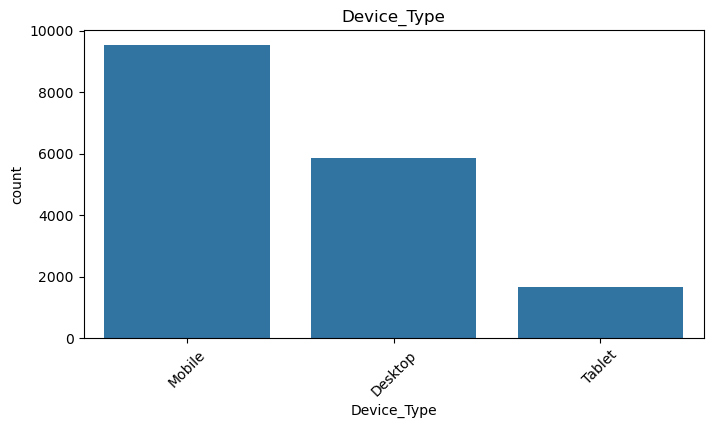

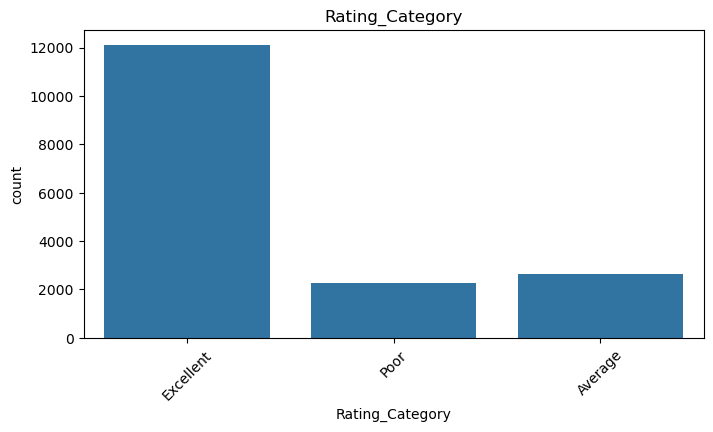

In [46]:
for col in cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

# Categorical Variable Analysis

The categorical analysis reveals several important business insights:

- Bengaluru is the largest customer market in the dataset.
- Product demand is well balanced across all product categories.
- Customers predominantly prefer digital payment methods, with Credit Cards being the most frequently used.
- Mobile devices are the primary platform for online shopping.
- Customer satisfaction is consistently high, as reflected by the large proportion of Excellent ratings.
